1. 깃허브 자신의 계정에 수업과 숙제를 올린 소스코드만 참조가능

(그 외의 참조는 부정으로 간주 F처리)



# 데이터 로드
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
data = pd.read_csv(url, names=columns)

# 데이터 확인
print(data.head())

2. 해당 소스를 이용하여 ML 분류 RF, LR, DT

3. 해당 소스를 이용하여 FCNN

4. 해당 소스를 이용하여 CNN

5. 모든 소스에는 F1값 및 confusion matrix 표시



In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [121]:
url='https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'] 
data = pd.read_csv(url, names=columns)
data

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [122]:
data=df

In [123]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2
...,...,...,...,...,...,...,...
1723,1,1,3,2,1,2,1
1724,1,1,3,2,1,0,3
1725,1,1,3,2,0,1,2
1726,1,1,3,2,0,2,1


In [124]:
label_encoder = LabelEncoder()
df['buying'] = label_encoder.fit_transform(df['buying'])
label_encoder = LabelEncoder()
df['maint'] = label_encoder.fit_transform(df['maint'])
label_encoder = LabelEncoder()
df['doors'] = label_encoder.fit_transform(df['doors'])
label_encoder = LabelEncoder()
df['persons'] = label_encoder.fit_transform(df['persons'])
label_encoder = LabelEncoder()
df['lug_boot'] = label_encoder.fit_transform(df['lug_boot'])
label_encoder = LabelEncoder()
df['safety'] = label_encoder.fit_transform(df['safety'])
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])

In [125]:
X=df.drop('class',axis=1)
X.head()

,buying,maint,doors,persons,lug_boot,safety
0,3,3,0,0,2,1
1,3,3,0,0,2,2
2,3,3,0,0,2,0
3,3,3,0,0,1,1
4,3,3,0,0,1,2


In [126]:
y=df['class']
y.value_counts()

class
2    1210
0     384
1      69
3      65
Name: count, dtype: int64

In [127]:
y.head()

0    2
1    2
2    2
3    2
4    2
Name: class, dtype: int64

In [128]:
Y = pd.get_dummies(y).values

In [129]:
X = X.values

In [130]:
X
Y

array([[False, False,  True, False],
       [False, False,  True, False],
       [False, False,  True, False],
       ...,
       [False, False,  True, False],
       [False,  True, False, False],
       [False, False, False,  True]])

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.25,random_state=0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1296, 6) (432, 6) (1296, 4) (432, 4)


In [153]:
def split_sequences(sequences,n_features, n_steps):
	X, y = list(), list()
	for i in range(len(sequences)):
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [142]:
X_train, y_train = split_sequences(X_train,n_features, X_test.shape[1])
print(X_train.shape, y_train.shape)

X_test, y_test = split_sequences(X_test,n_features, X_test.shape[1])
print(X_test.shape, y_test.shape)  

(1286, 6, 5, 1, 6) (1286, 1, 6)
(422, 6, 5, 1, 6) (422, 1, 6)


In [143]:
# 각각 스텝 수, feature 수, label 수
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[1], y_train.shape[1]
print(n_timesteps, n_features, n_outputs)

6 6 1


In [145]:
# 입력 데이터 형식 확인
print(f"Original X_train shape: {X_train.shape}")
print(f"Original X_test shape: {X_test.shape}")

# 입력 데이터 형식 변경
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
print(f"Reshaped X_train shape: {X_train.shape}")
print(f"Reshaped X_test shape: {X_test.shape}")

Original X_train shape: (1296, 6)
Original X_test shape: (432, 6)
Reshaped X_train shape: (1296, 1, 6)
Reshaped X_test shape: (432, 1, 6)


In [146]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import Input
from keras.layers import Dense, Flatten, Dropout

In [147]:
import tensorflow as tf

n_features = 6
n_timesteps = 1

input_layer = Input(shape=(n_timesteps,n_features))

conv1 = Conv1D(filters=64, kernel_size=1, activation='relu')(input_layer) 
flat = Flatten()(conv1)
dens = Dense(64, activation = "relu")(flat)
outputs = Dense(4, activation = "sigmoid")(dens)

model = keras.Model(input_layer, outputs)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 1, 6)]            0         
                                                                 
 conv1d_8 (Conv1D)           (None, 1, 64)             448       
                                                                 
 flatten_8 (Flatten)         (None, 64)                0         
                                                                 
 dense_16 (Dense)            (None, 64)                4160      
                                                                 
 dense_17 (Dense)            (None, 4)                 260       
                                                                 
Total params: 4,868
Trainable params: 4,868
Non-trainable params: 0
_________________________________________________________________


In [148]:
history=model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

Epoch 1/30
41/41 [==============================] - 1s 20ms/step - loss: 0.4677 - accuracy: 0.6389 - val_loss: 0.3669 - val_accuracy: 0.6852
Epoch 2/30
41/41 [==============================] - 1s 34ms/step - loss: 0.3372 - accuracy: 0.7076 - val_loss: 0.3383 - val_accuracy: 0.6898
Epoch 3/30
41/41 [==============================] - 2s 38ms/step - loss: 0.3137 - accuracy: 0.7099 - val_loss: 0.3194 - val_accuracy: 0.6782
Epoch 4/30
41/41 [==============================] - 2s 41ms/step - loss: 0.3000 - accuracy: 0.7168 - val_loss: 0.3090 - val_accuracy: 0.6736
Epoch 5/30
41/41 [==============================] - 2s 39ms/step - loss: 0.2889 - accuracy: 0.7261 - val_loss: 0.2959 - val_accuracy: 0.6806
Epoch 6/30
41/41 [==============================] - 2s 40ms/step - loss: 0.2772 - accuracy: 0.7299 - val_loss: 0.2878 - val_accuracy: 0.6921
Epoch 7/30
41/41 [==============================] - 2s 39ms/step - loss: 0.2660 - accuracy: 0.7492 - val_loss: 0.2731 - val_accuracy: 0.7083
Epoch 8/30
41

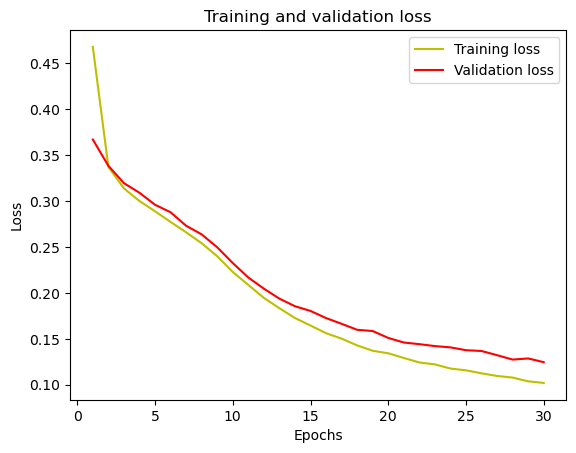

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =history.history['loss']
val_loss =history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [150]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.73      0.77      0.75        99
           1       1.00      0.10      0.17        21
           2       0.93      0.99      0.96       296
           3       0.83      0.62      0.71        16

    accuracy                           0.88       432
   macro avg       0.87      0.62      0.65       432
weighted avg       0.88      0.88      0.86       432

[[ 76   0  22   1]
 [ 18   2   0   1]
 [  4   0 292   0]
 [  6   0   0  10]]
